<div class="markdown-google-sans">

## <strong>Импорт необходимых библиотек, модели для обучения, а также распаковка набора данных</strong>
</div>

In [ ]:
from IPython.display import clear_output
import cv2
!pip3 install google-colab
from google.colab.patches import cv2_imshow
clear_output()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/My Drive/weapon_data.zip" -d /content/

In [ ]:
# Скачивание репозитория с YOLOv5 и необходимых библиотек для работы модели
!git clone https://github.com/ultralytics/yolov5
!pip install -r ./yolov5/requirements.txt
# clear_output()

fatal: destination path 'yolov5' already exists and is not an empty directory.


In [ ]:
# !rm ./yolov5/data/custom.yaml
!touch ./yolov5/data/custom.yaml

In [ ]:
# Создаём файл для собственной структуры датасета
!touch ./yolov5/data/custom.yaml

# Запишите в созданный файл (изображение ниже) следующий текст
# для этого можно просто двойным нажатием ЛКМ открыть его, вставить информацию
# и сохранить сочетанием ctrl+s
# Примерная структура датасета. В случае если называете директории по другому, измените их название
"""
train: ../weapon_data/images/train/
val:  ../weapon_data/images/val/
test: ../weapon_data/images/test/
# number of classes,
nc: 1,
# class names,
names: ["weapon"]
"""

# Записываем в созданный ранее файл структуру датасете
my_file = open('/content/yolov5/data/custom.yaml','w+')
my_file.write('train: ../weapon_data/images/train/ \nval:  ../weapon_data/images/val/ \ntest: ../weapon_data/images/test/ \n# number of classes \nnc: 1 \n# class names \nnames: ["weapon"]')

166

In [ ]:
yaml_text = """
train: /content/weapon_data/images/train/
val: /content/weapon_data/images/val/
test: /content/weapon_data/images/test/

nc: 1
names: ['weapon']
"""

with open('/content/yolov5/data/custom.yaml', 'w') as f:
    f.write(yaml_text.strip())

# Проверка, что всё записалось красиво
with open('/content/yolov5/data/custom.yaml', 'r') as f:
    print(f.read())

train: /content/weapon_data/images/train/
val: /content/weapon_data/images/val/
test: /content/weapon_data/images/test/

nc: 1
names: ['weapon']


In [ ]:
# Проверка записи в файл структуры. Если вывод пустой, повторно запустите предыдущую ячейку
my_file.readlines()

[]

In [ ]:
!pip install imageio
!pip install imutils
clear_output()

In [ ]:
import random
from PIL import Image, ImageDraw
import numpy as np
from numpy import int64
import matplotlib.pyplot as plt
import os
import glob
from imageio import imread
import cv2
from google.colab.patches import cv2_imshow
import imutils
import json

import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import load_img
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as K

import torch
# from IPython.display import Image
import os
import random
import shutil
from sklearn.model_selection import train_test_split
import xml.etree.ElementTree as ET
from xml.dom import minidom
from tqdm import tqdm
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

ERROR:absl:Detected incompatible Protobuf Gencode/Runtime versions when loading tensorflow_metadata/proto/v0/anomalies.proto: gencode 6.31.1 runtime 5.29.6. Runtime version cannot be older than the linked gencode version. See Protobuf version guarantees at https://protobuf.dev/support/cross-version-runtime-guarantee.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py", line 79, in <module>
    from tensorflow_datasets import rlds  # pylint: disable=g-bad-import-order
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/__init__.py", line 21, in <module>
    from tensorflow_datasets.rlds import envlogger_reader
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/rlds/envlogger_reader.py", line 21, in <module>
    from tensorflow_datasets.core.utils.lazy_imports_utils import tree
  File "/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/co

In [ ]:
from google.colab import drive
import os
import glob

drive.mount('/content/gdrive')
root = '/gdrive/My Drive/'

Mounted at /content/gdrive


In [ ]:
# !unzip weapon_data.zip -d /content/yolov5
!unzip '/content/gdrive/MyDrive/weapon_data.zip' -d /content/yolov5

Archive:  /content/gdrive/MyDrive/weapon_data.zip
   creating: /content/yolov5/weapon_data/
   creating: /content/yolov5/weapon_data/images/
   creating: /content/yolov5/weapon_data/images/test/
  inflating: /content/yolov5/weapon_data/images/test/im16.jpg  
  inflating: /content/yolov5/weapon_data/images/test/im2.jpg  
  inflating: /content/yolov5/weapon_data/images/test/im31.jpg  
  inflating: /content/yolov5/weapon_data/images/test/im33.jpg  
  inflating: /content/yolov5/weapon_data/images/test/im45.jpg  
  inflating: /content/yolov5/weapon_data/images/test/im61.jpg  
  inflating: /content/yolov5/weapon_data/images/test/im62.jpg  
  inflating: /content/yolov5/weapon_data/images/test/im64.jpg  
  inflating: /content/yolov5/weapon_data/images/test/im66.jpg  
  inflating: /content/yolov5/weapon_data/images/test/im9.jpg  
   creating: /content/yolov5/weapon_data/images/train/
  inflating: /content/yolov5/weapon_data/images/train/1.jpg  
  inflating: /content/yolov5/weapon_data/images/tr

<div class="markdown-google-sans">

## <strong>Предобработка датасета</strong>
</div>

In [ ]:
# def move_files_to_folder(list_of_files, destination_folder):
#     for f in list_of_files:
#         try:
#             shutil.copy(f, destination_folder)
#         except:
#             print(f)
#             assert False

In [ ]:
# # Создаём папки для хранения датасета на "внешнем" хранилище, чтобы можно было из изменять
# !mkdir ./yolov5/weapon_data
# !mkdir ./yolov5/weapon_data/images ./yolov5/weapon_data/labels
# # Создаём папки для хранения выборок
# !mkdir ./yolov5/weapon_data/images/train ./yolov5/weapon_data/images/val ./yolov5/weapon_data/images/test ./yolov5/weapon_data/labels/train ./yolov5/weapon_data/labels/val ./yolov5/weapon_data/labels/test

In [ ]:
# # Определеяем пути к папкам выборок изображений и разметок
originTrainImgs = "/content/yolov5/weapon_data/images/train/"
originTestImgs = "/content/yolov5/weapon_data/images/test/"
originValImgs = "/content/yolov5/weapon_data/images/val/"

originTrainLabls = "/content/yolov5/weapon_data/labels/train/"
originTestLabls = "/content/yolov5/weapon_data/labels/test/"
originValLabls = "/content/yolov5/weapon_data/labels/val/"

# # Создаём пустые списки для хранения путей к изображениям
images = []
# train_images = []
# test_images = []
# val_images = []

# # Копируем изображения из "внутреннего" датасета в ранее созданные папки выборок
for fl in sorted(os.listdir(originTrainImgs)):
    images.append(originTrainImgs+fl)
    # train_images.append(originTrainImgs+fl)
# move_files_to_folder(train_images, "./yolov5/weapon_data/images/train/")
for fl in sorted(os.listdir(originTestImgs)):
    images.append(originTestImgs+fl)
    # test_images.append(originTestImgs+fl)
# move_files_to_folder(test_images, "./yolov5/weapon_data/images/test/")
for fl in sorted(os.listdir(originValImgs)):
    images.append(originValImgs+fl)
    # val_images.append(originValImgs+fl)
# move_files_to_folder(val_images, "./yolov5/weapon_data/images/val/")

# # Повторяем процедуру для файлов разметки
annotations = []
# train_annotations = []
# test_annotations = []
# val_annotations = []

for fl in sorted(os.listdir(originTrainLabls)):
    annotations.append(originTrainLabls+fl)
#     train_annotations.append(originTrainLabls+fl)
# move_files_to_folder(train_annotations, "./yolov5/weapon_data/labels/train/")
for fl in sorted(os.listdir(originTestLabls)):
    annotations.append(originTestLabls+fl)
#     test_annotations.append(originTestLabls+fl)
# move_files_to_folder(test_annotations, "./yolov5/weapon_data/labels/test/")
for fl in sorted(os.listdir(originValLabls)):
    annotations.append(originValLabls+fl)
#     val_annotations.append(originValLabls+fl)
# move_files_to_folder(val_annotations, "./yolov5/weapon_data/labels/val/")

# # print(images)

In [ ]:
print(len(images))

98


In [ ]:
# Проверка наличия файлов в папках тестовой выборки (должно быть по 10 файлов, файлы должны совпадать)
!ls ./yolov5/weapon_data/images/test/
print('--------------')
!ls ./yolov5/weapon_data/labels/test/

im16.jpg  im31.jpg  im45.jpg  im62.jpg	im66.jpg
im2.jpg   im33.jpg  im61.jpg  im64.jpg	im9.jpg
--------------
im16.txt  im31.txt  im45.txt  im62.txt	im66.txt
im2.txt   im33.txt  im61.txt  im64.txt	im9.txt


В тестовой выборке должны быть следующие файлы: im2.jpg, im9.jpg, im16.jpg, im31.jpg, im33.jpg, im45.jpg, im61.jpg, im62.jpg, im64.jpg, im66.jpg,

In [ ]:
"""
Эта ячейка очищает директории с выборками, хранящимеся в директории yolov5.
ЗАПУСКАТЬ ТОЛЬКО В СЛУЧАЕ, ЕСЛИ ПРИ КОПИРОВАНИИ ПРОИЗОШЛА ОШИБКА, И НАДО ПОВТОРИТЬ ПРОЦЕДУРУ
"""

# Определяем пути к папкам с файлами разметки
labelsTrain = "./yolov5/weapon_data/labels/train/"
labelsTest = "./yolov5/weapon_data/labels/test/"
labelsVal = "./yolov5/weapon_data/labels/val/"

# Удаляем файлы во всех трёх папках
for fl in sorted(os.listdir(labelsTrain)):
    os.remove(labelsTrain+fl)

for fl in sorted(os.listdir(labelsTest)):
    os.remove(labelsTest+fl)

for fl in sorted(os.listdir(labelsVal)):
    os.remove(labelsVal+fl)

# Повторяем для изображений
imgTrain = "./yolov5/weapon_data/images/train/"
imgTest = "./yolov5/weapon_data/images/test/"
imgVal = "./yolov5/weapon_data/images/val/"

for fl in sorted(os.listdir(imgTrain)):
    os.remove(imgTrain+fl)

for fl in sorted(os.listdir(imgTest)):
    os.remove(imgTest+fl)

for fl in sorted(os.listdir(imgVal)):
    os.remove(imgVal+fl)

!rm -r /content/yolov5/weapon_data

In [ ]:
imgTrain = "./yolov5/weapon_data/images/train/"
imgTest = "./yolov5/weapon_data/images/test/"
imgVal = "./yolov5/weapon_data/images/val/"
labelsTrain = "./yolov5/weapon_data/labels/train/"
labelsTest = "./yolov5/weapon_data/labels/test/"
labelsVal = "./yolov5/weapon_data/labels/val/"

def brightness(img, low, high):
    value = random.uniform(low, high)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv = np.array(hsv, dtype = np.float64)
    hsv[:,:,1] = hsv[:,:,1]*value
    hsv[:,:,1][hsv[:,:,1]>255]  = 255
    hsv[:,:,2] = hsv[:,:,2]*value
    hsv[:,:,2][hsv[:,:,2]>255]  = 255
    hsv = np.array(hsv, dtype = np.uint8)
    img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    return img

def augmentFilesInDir(pathToDir):
#     Реализуйте код для аугментации файлов в директории указанной выборки
    for fl in sorted(os.listdir(pathToDir)):
#         Место для вашего кода
#         Учтите, что по заданию вам необходимо расширить файлы ы каждой выборки в 2 раза
        if(".jpg" in fl):
            # Считываем изображение
            img = cv2.imread(pathToDir+fl)
            # Изменяем изобраение
            img = brightness(img, 0.5, 1.5)
            # Раздлеяем исходное название чтобы избавиться от расширения ".jpg"
#             tmp = fl.split('/')
            tmp1 = fl.split('.')
            # Инициализируем новое название с желанным расширением изображения
            newFl = tmp1[0]+'_1.jpg'
#             print(newFl)
            # Сохраняем изменённое изображение в отдельной директории (в задании директорию менять не обязательно)
            cv2.imwrite(pathToDir+newFl, img)
        else:
            tmp = fl.split('.')
            newFl = tmp[0]+'_1.txt'
#             print(newFl)
            shutil.copy(pathToDir+fl, pathToDir+newFl)

# Вызов реализованной вами функции для расширения выборок
augmentFilesInDir(labelsTrain)
augmentFilesInDir(imgTrain)

augmentFilesInDir(labelsTest)
augmentFilesInDir(imgTest)

augmentFilesInDir(labelsVal)
augmentFilesInDir(imgVal)

In [ ]:
import os
import cv2
import random
import numpy as np
import shutil

imgTrain = "/content/yolov5/weapon_data/images/train/"
imgTest = "/content/yolov5/weapon_data/images/test/"
imgVal = "/content/yolov5/weapon_data/images/val/"
labelsTrain = "/content/yolov5/weapon_data/labels/train/"
labelsTest = "/content/yolov5/weapon_data/labels/test/"
labelsVal = "/content/yolov5/weapon_data/labels/val/"

def brightness(img, low, high):
    value = random.uniform(low, high)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv = np.array(hsv, dtype=np.float64)
    hsv[:,:,1] = hsv[:,:,1] * value
    hsv[:,:,1][hsv[:,:,1] > 255] = 255
    hsv[:,:,2] = hsv[:,:,2] * value
    hsv[:,:,2][hsv[:,:,2] > 255] = 255
    hsv = np.array(hsv, dtype=np.uint8)
    img = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    return img

def augmentFilesInDir(pathToDir):
    for f1 in sorted(os.listdir(pathToDir)):
        if ".jpg" in f1:
            # Читаем картинку, меняем яркость
            img = cv2.imread(os.path.join(pathToDir, f1))
            img = brightness(img, 0.5, 1.5)

            # Создаем новое имя для аугментированной картинки
            tmp = f1.split('.')
            newF1 = tmp[0] + '_1.jpg'

            # Сохраняем измененное изображение
            cv2.imwrite(os.path.join(pathToDir, newF1), img)

        elif ".txt" in f1:
            # Для текстовых файлов разметки просто делаем копию с новым именем
            tmp = f1.split('.')
            newF1 = tmp[0] + '_1.txt'
            shutil.copy(os.path.join(pathToDir, f1), os.path.join(pathToDir, newF1))

# Запуск аугментации для всех папок данных и разметки
augmentFilesInDir(labelsTrain)
augmentFilesInDir(imgTrain)

augmentFilesInDir(labelsTest)
augmentFilesInDir(imgTest)

augmentFilesInDir(labelsVal)
augmentFilesInDir(imgVal)

print("Аугментация успешно завершена! Выборка увеличена в 2 раза.")

Аугментация успешно завершена! Выборка увеличена в 2 раза.


In [ ]:
!ls ./yolov5/weapon_data/images/test/
print('-----------------')
!ls ./yolov5/weapon_data/labels/test/

im16_1.jpg  im31_1.jpg	im45_1.jpg  im62_1.jpg	im66_1.jpg
im16.jpg    im31.jpg	im45.jpg    im62.jpg	im66.jpg
im2_1.jpg   im33_1.jpg	im61_1.jpg  im64_1.jpg	im9_1.jpg
im2.jpg     im33.jpg	im61.jpg    im64.jpg	im9.jpg
-----------------
im16_1.txt  im31_1.txt	im45_1.txt  im62_1.txt	im66_1.txt
im16.txt    im31.txt	im45.txt    im62.txt	im66.txt
im2_1.txt   im33_1.txt	im61_1.txt  im64_1.txt	im9_1.txt
im2.txt     im33.txt	im61.txt    im64.txt	im9.txt


In [ ]:
import glob
from PIL import Image

imagepath = '/content/yolov5/weapon_data/images/train/'

imgs_names = glob.glob(imagepath+'*.jpg')

broken=[]
for imgname in imgs_names:
    try:
      img = Image.open(imgname)
    except:
      broken.append(imgname)
print(broken)
print(len(broken))

imagepath = '/content/yolov5/weapon_data/images/val/'

imgs_names = glob.glob(imagepath+'*.jpg')

broken=[]
for imgname in imgs_names:
    try:
      img = Image.open(imgname)
    except:
      broken.append(imgname)
print(broken)
print(len(broken))

imagepath = '/content/yolov5/weapon_data/images/test/'

imgs_names = glob.glob(imagepath+'*.jpg')

broken=[]
for imgname in imgs_names:
    try:
      img = Image.open(imgname)
    except:
      broken.append(imgname)
print(broken)
print(len(broken))

[]
0
[]
0
[]
0


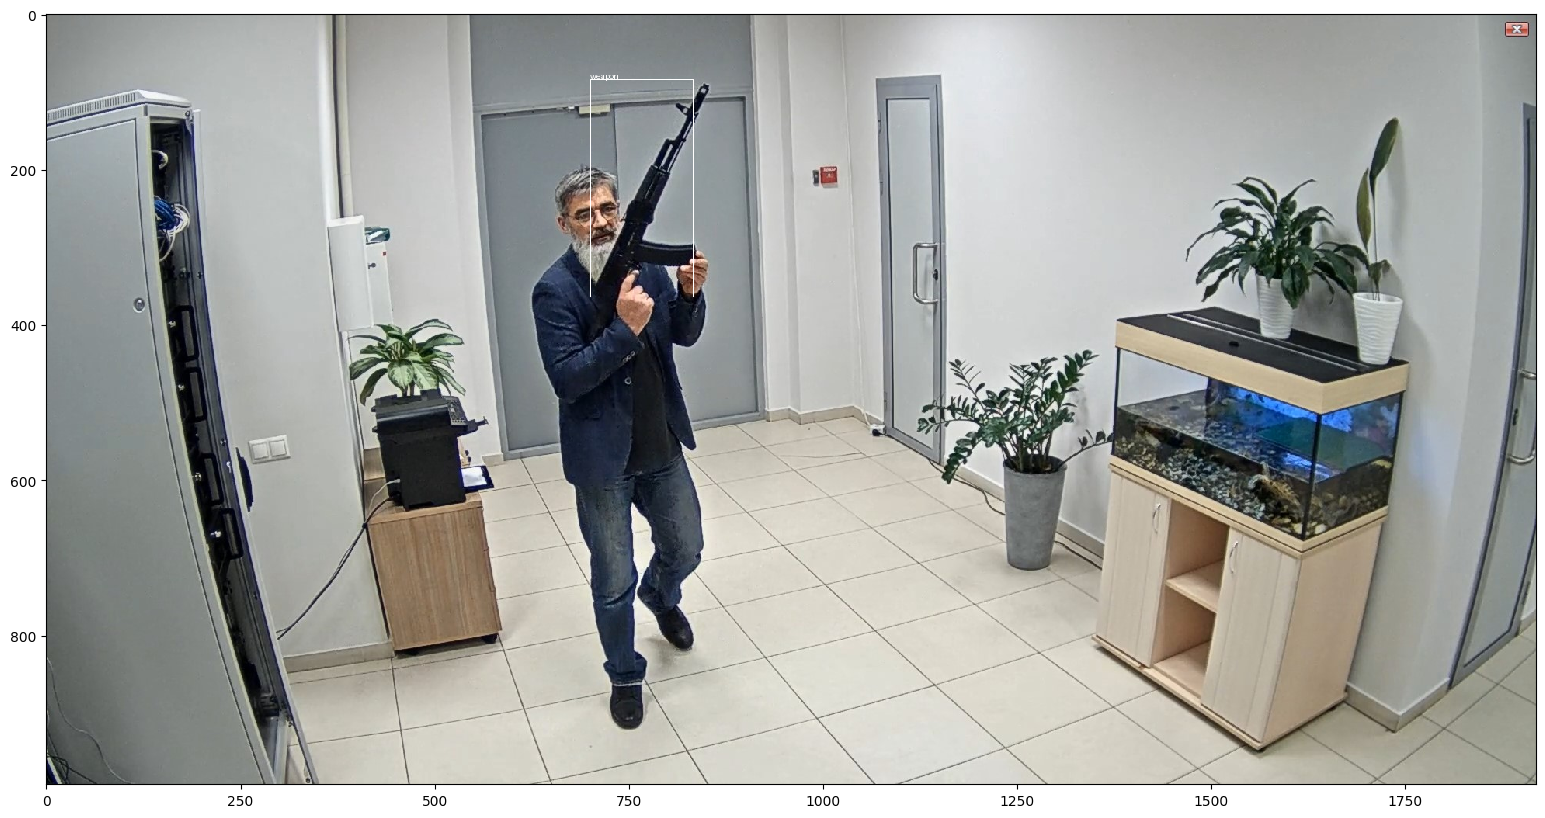

In [ ]:
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Определение id классов объектов
class_name_to_id_mapping = {"weapon": 0,}

# Установка сида рандомной генерации
random.seed(0)

# Определяем словарь с id классов
class_id_to_name_mapping = dict(zip(class_name_to_id_mapping.values(), class_name_to_id_mapping.keys()))

# Функция для демонстрации разметки
def plot_bounding_box(image, annotation_list):
    annotations = np.array(annotation_list)

    # Получаем размер изображения
    w, h = image.size

    # Выводим исходное изображение
    plotted_image = ImageDraw.Draw(image)

    # Конвертируем координаты для показа
    transformed_annotations = np.copy(annotations)
    transformed_annotations[:,[1,3]] = annotations[:,[1,3]] * w
    transformed_annotations[:,[2,4]] = annotations[:,[2,4]] * h

    transformed_annotations[:,1] = transformed_annotations[:,1] - (transformed_annotations[:,3] / 2)
    transformed_annotations[:,2] = transformed_annotations[:,2] - (transformed_annotations[:,4] / 2)
    transformed_annotations[:,3] = transformed_annotations[:,1] + transformed_annotations[:,3]
    transformed_annotations[:,4] = transformed_annotations[:,2] + transformed_annotations[:,4]

    # Вывод разметки и классов объектов
    for ann in transformed_annotations:
        obj_cls, x0, y0, x1, y1 = ann
        plotted_image.rectangle(((x0,y0), (x1,y1)))

        plotted_image.text((x0, y0 - 10), class_id_to_name_mapping[(int(obj_cls))])

    plt.figure(figsize = (30,10))
    plt.imshow(np.array(image), interpolation='nearest')
    plt.show()

# Выбираем случайный файл разметки
annotation_file = random.choice(annotations)
with open(annotation_file, "r") as file:
    annotation_list = file.read().split("\n")[:-1]
    annotation_list = [x.split(" ") for x in annotation_list]
    annotation_list = [[float(y) for y in x ] for x in annotation_list]

# Получаем соответствующий файл с разметкой
image_file = annotation_file.replace("labels", "images").replace("txt", "jpg")
assert os.path.exists(image_file)

# Загрузка изображения
image = Image.open(image_file)

# Показ разметки
plot_bounding_box(image, annotation_list)

Вариация верхнего блока, но для вывода разметки всех изображений датасета

**Запускать на свой страх и риск, или только в случае необходимости наглядной проверки разметки, ибо из-за большого количества изображений может зависнуть браузер**

In [ ]:
# Определение id классов объектов
class_name_to_id_mapping = {"weapon": 0}

# Установка сида рандомной генерации
random.seed(0)

# Определяем словарь с id классов
class_id_to_name_mapping = dict(zip(class_name_to_id_mapping.values(), class_name_to_id_mapping.keys()))

# Функция для демонстрации разметки
def plot_bounding_box(image, annotation_list):
    annotations = np.array(annotation_list)

    # Получаем размер изображения
    w, h = image.size

    # Выводим исходное изображение
    plotted_image = ImageDraw.Draw(image)

    # Конвертируем координаты для показа
    transformed_annotations = np.copy(annotations)
    transformed_annotations[:,[1,3]] = annotations[:,[1,3]] * w
    transformed_annotations[:,[2,4]] = annotations[:,[2,4]] * h

    transformed_annotations[:,1] = transformed_annotations[:,1] - (transformed_annotations[:,3] / 2)
    transformed_annotations[:,2] = transformed_annotations[:,2] - (transformed_annotations[:,4] / 2)
    transformed_annotations[:,3] = transformed_annotations[:,1] + transformed_annotations[:,3]
    transformed_annotations[:,4] = transformed_annotations[:,2] + transformed_annotations[:,4]

    # Вывод разметки и классов объектов
    for ann in transformed_annotations:
        obj_cls, x0, y0, x1, y1 = ann
        plotted_image.rectangle(((x0,y0), (x1,y1)))

        plotted_image.text((x0, y0 - 10), class_id_to_name_mapping[(int(obj_cls))])

    plt.figure(figsize = (15,5))
    plt.imshow(np.array(image), interpolation='nearest')
    plt.show()

# Получаем путь к каждому файлу разметки из списка
for annotation_file in annotations:
  # Открываем файл в режиме чтения
  with open(annotation_file, "r") as file:
    # Разделяем весь текст в файле по строчно
    annotation_list = file.read().split("\n")[:-1]
    # Разделяем кажду строку на отедльные координаты и класс, ориентируясь на пробелы
    annotation_list = [x.split(" ") for x in annotation_list]
    # Переводим координаты в числовой вид
    annotation_list = [[float(y) for y in x ] for x in annotation_list]
  # Получаем путь к нужному изображения, меняя папку в пути и формат файла
  image_file = annotation_file.replace("labels", "images").replace("txt", "jpg")
  # Проверяем, существует ли такое изображение
  assert os.path.exists(image_file)
  # Открываем изображение
  image = Image.open(image_file)
  # Выводим изображение и его разметку
  plot_bounding_box(image, annotation_list)
  # Выводим название изображения для простой навигации
  print(image_file)

Output hidden; open in https://colab.research.google.com to view.

<div class="markdown-google-sans">

## <strong>Обучение и тестирование модели</strong>
</div>

In [ ]:
# Переходим в директорию yolov5
%cd ./yolov5

[Errno 2] No such file or directory: './yolov5'
/content/yolov5


In [ ]:
!rm -rf /content/weapon_data/images/train.cache
!rm -rf /content/weapon_data/images/val.cache
!rm -rf /content/yolov5/weapon_data/images/train.cache
!rm -rf /content/yolov5/weapon_data/images/val.cache
print("Кэш успешно очищен!")

Кэш успешно очищен!


In [ ]:
# Запуск обучения с указанием параметров
# Измените параметры обучения так, чтобы добиться наилучших показателей

# Вы можете использовать различные модели, представленные в директории "/content/yolov5/models/"
# Информация с обучением разных моделей имеется в официальном репозитории: https://github.com/ultralytics/yolov5
# При выборе другой модели, не забудьте сменить веса для модели

#                img size  |  model config                               batch size|num of epochs |           dataset       | weights for model               |   name of model
#!python train.py --img 640 --cfg yolov5s.yaml --hyp hyp.scratch-med.yaml --batch 32 --epochs 50 --data ./data/custom.yaml --weights yolov5s.pt --workers 24 --name yolo_weapon_det
!python train.py --img 640 --cfg yolov5s.yaml --hyp hyp.scratch-high.yaml --batch 16 --epochs 80 --data /content/yolov5/data/custom.yaml --name yolow_weapon_final --exist-ok

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train: weights=yolov5s.pt, cfg=yolov5s.yaml, data=/content/yolov5/data/custom.yaml, hyp=hyp.scratch-high.yaml, epochs=80, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/train, name=yolow_weapon_final, exist_ok=True, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze

In [ ]:
# Запуск детектирования на тестовой выборке
#!python detect.py --source ./weapon_data/images/test/ --weights runs/train/yolo_weapon_det/weights/best.pt --conf 0.25 --name yolo_weapon_det
#!python detect.py --source ./weapon_data/images/test/ --weights runs/train/yolo_weapon_det/weights/best.pt --conf 0.25 --name yolo_weapon_det
#!python detect.py --source /content/weapon_data/images/test/ --weights runs/train/yolo_weapon_final/weights/best.pt --name exp_final --exist-ok
!python detect.py --source /content/weapon_data/images/test/ --weights /content/yolov5/runs/train/yolo_weapon_final/weights/best.pt --name exp_final --exist-ok

detect: weights=['/content/yolov5/runs/train/yolo_weapon_final/weights/best.pt'], source=/content/weapon_data/images/test/, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp_final, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-509-gfd0f6da7 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Traceback (most recent call last):
  File "/content/yolov5/detect.py", line 444, in <module>
    main(opt)
  File "/content/yolov5/detect.py", line 439, in main
    run(**vars(opt))
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

In [ ]:
# Определяем путь к тестовой выборке
detections_dir = "./runs/detect/exp_final/"
detection_images = [os.path.join(detections_dir, x) for x in os.listdir(detections_dir)]

# Вывод изображения с результатами детектирования
# random_detection_image = Image.open(random.choice(detection_images))
# plt.figure(figsize = (30,10))
# plt.imshow(np.array(random_detection_image))
for fl in os.listdir(detections_dir):
  img = cv2.imread(detections_dir+fl)
  img = imutils.resize(img, width=600)
  cv2_imshow(img)

In [ ]:
# Запуск тестирования обученной модели, для получения метрик
# Результаты метрики mAP50-95 для всех классов (all) являются результатами обучения модели на тестовой выборке
print('test results:')
!python val.py --weights ./runs/train/yolo_weapon_final/weights/best.pt --data custom.yaml --task test --name yolo_weapon_det_test

test results:
val: data=/content/yolov5/data/custom.yaml, weights=['./runs/train/yolo_weapon_final/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=yolo_weapon_det_test, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-509-gfd0f6da7 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Traceback (most recent call last):
  File "/content/yolov5/val.py", line 527, in <module>
    main(opt)
  File "/content/yolov5/val.py", line 498, in main
    run(**vars(opt))
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/_contextlib.py", line 124, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/content/yolov5/val.py", line 195, in run
    model = DetectMultiBackend(weights, device=device, dnn=dnn, data=data, fp16=half)
   

In [ ]:
# Замените на свои ФИО
name = 'Shapovalova Ta'
# Замените на полученную точность согласно метрики mAP50 для всех классов (all)
acc = 0.846
print(name, ', mAP50:', acc)
# print('mAP50:', acc)

Shapovalova Ta , mAP50: 0.846
